# In-Silico Cancer Vaccine Designer
### Simulating the personalized neoantigen vaccine pipeline with a vector database

*DS4300 — HW5 NoSQL R&D Project (Data Science Application)*

---

**Motivation.** At Yale, Dr. Mark Mamula's lab developed a cancer vaccine for dogs that
targets the **EGFR** and **HER2** proteins over-expressed on many tumors — work he began
after losing his own dog to an inoperable cancer. One patient, a search-and-rescue dog
named Hunter, has had no evidence of cancer after treatment. Human "personalized cancer
vaccines" (e.g. mRNA neoantigen vaccines) follow a related idea: teach the immune system
to recognize proteins that are abnormal *only* in tumor cells.

But how is such a vaccine actually *designed*? This project simulates the core
**computational pipeline** that turns a tumor's mutations into a ranked set of vaccine
targets, and uses a **NoSQL vector database (ChromaDB)** as its scientific engine: we
rank candidate neoantigens by how similar they are to *known immunogenic epitopes*.

> **Scope & honesty.** This is a **simplified, educational simulation.** Real pipelines use
> whole-exome sequencing, neural-network binding predictors (e.g. NetMHCpan), and
> laboratory validation. We reproduce the *essential ideas*, not clinical-grade prediction.

## The pipeline at a glance

1. **Load** human cancer-driver proteins (EGFR, HER2, KRAS, TP53) from UniProt.
2. **Mutate** them with real recurrent oncogenic point mutations and slice out every
   mutation-spanning **9-mer** (the length MHC class I presents to T cells).
3. **Score** each candidate neoantigen:
   - *Binding* — an HLA-A\*02:01 anchor-residue heuristic.
   - *Similarity* — a nearest-neighbor query against a **Chroma vector DB** of known
     immunogenic epitopes.
4. **Rank** candidates and **assemble** a "string-of-beads" vaccine construct.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from vaxsim import (
    load_all_proteins, HOTSPOT_MUTATIONS, REFERENCE_EPITOPES,
    EpitopeStore, score_candidates, design_vaccine,
    generate_neoepitopes, embed_many, EMBED_DIM,
)

plt.rcParams["figure.dpi"] = 120
FIG = os.path.abspath("../figures")
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.max_colwidth", 30)
print("peptide embedding dimensionality:", EMBED_DIM)

peptide embedding dimensionality: 47


## Stage 1 — Cancer-driver proteins

We pull four canonical human oncoproteins from UniProt. EGFR and HER2 are exactly the
targets of the Yale canine vaccine; KRAS and TP53 are the two most frequently mutated
genes in human cancer.

In [2]:
proteins = load_all_proteins()
pd.DataFrame(
    [(name, len(seq), seq[:30] + "...") for name, seq in proteins.items()],
    columns=["protein", "length (aa)", "sequence (start)"],
)

,protein,length (aa),sequence (start)
0,EGFR,1210,MRPSGTAGAALLALLAALCPASRALE...
1,HER2,1255,MELAALCRWGLLLALLPPGAASTQVC...
2,KRAS,189,MTEYKLVVVGAGGVGKSALTIQLIQN...
3,TP53,393,MEEPQSDPSVEPPLSQETFSDLWKLL...


## Stage 2 — The NoSQL vector database (ChromaDB)

This is the heart of the project. We embed each curated **known immunogenic epitope**
(published HLA-A\*02:01 CD8+ T-cell epitopes — viral and tumor-associated) into a
47-dimensional physicochemical feature vector and store it in a persistent Chroma
collection using **cosine** distance.

A vector database is a NoSQL store optimized for one question: *"what stored items are
most similar to this query vector?"* — exactly what we need to ask of new neoantigens.

In [3]:
store = EpitopeStore()
n = store.build(reset=True)
print(f"Chroma collection '{store.collection.name}' now holds {n} known epitopes.")

cats = pd.Series([c for _, _, c in REFERENCE_EPITOPES]).value_counts()
print("\nReference epitopes by category:")
print(cats.to_string())

Chroma collection 'known_epitopes' now holds 32 known epitopes.

Reference epitopes by category:
tumor    24
viral     8


### Vector-DB query demo (the "query language")

Below we ask the database for the nearest known epitopes to a few peptides. This is the
core NoSQL operation: a similarity search returning ranked neighbors with metadata.

In [4]:
for q in ["NLVPMVATV", "KIFGSLAFL", "LVVVGADGV"]:  # CMV, HER2/neu, KRAS-G12D neoantigen
    print(f"query peptide: {q}")
    for hit in store.nearest(q, k=3):
        print(f"   {hit['similarity']:.3f}  {hit['epitope']:>10}  ({hit['antigen']}, {hit['category']})")
    print()

query peptide: NLVPMVATV
   1.000   NLVPMVATV  (CMV pp65, viral)
   0.833   GLCTLVAML  (EBV BMLF1, viral)
   0.677   SLLMWITQV  (NY-ESO-1, tumor)

query peptide: KIFGSLAFL
   1.000   KIFGSLAFL  (HER2/neu (E75), tumor)
   0.833   RMFPNAPYL  (WT1, tumor)
   0.618   SLYNTVATL  (HIV-1 Gag, viral)

query peptide: LVVVGADGV
   0.442   IISAVVGIL  (HER2/neu, tumor)
   0.442   VLDFAPPGA  (WT1, tumor)
   0.379   RLLQETELV  (HER2/neu, tumor)



## Stage 3 — Mutation → candidate neoantigens

For a point mutation, the altered residue can sit anywhere inside a presented 9-mer, so
we emit every mutation-spanning window. Here is the KRAS **G12D** mutation as an example —
note how each candidate differs from its wild-type ("self") counterpart at one position.

In [5]:
kras = proteins["KRAS"]
g12d = generate_neoepitopes("KRAS", kras, "G", 12, "D")
pd.DataFrame([
    {"peptide": n.peptide, "wildtype": n.wildtype_peptide,
     "mut_pos_in_9mer": n.mut_position_in_peptide, "novel": n.is_novel}
    for n in g12d
])

,peptide,wildtype,mut_pos_in_9mer,novel
0,YKLVVVGAD,YKLVVVGAG,9,True
1,KLVVVGADG,KLVVVGAGG,8,True
2,LVVVGADGV,LVVVGAGGV,7,True
3,VVVGADGVG,VVVGAGGVG,6,True
4,VVGADGVGK,VVGAGGVGK,5,True
5,VGADGVGKS,VGAGGVGKS,4,True
6,GADGVGKSA,GAGGVGKSA,3,True
7,ADGVGKSAL,AGGVGKSAL,2,True
8,DGVGKSALT,GGVGKSALT,1,True


## Stage 4 — Score every candidate

We combine the binding heuristic and the vector-DB similarity into a composite score
(equal weights). Higher = a more promising vaccine target.

In [6]:
df = score_candidates(store)
print(f"Scored {len(df)} candidate neoantigens across "
      f"{df['protein'].nunique()} proteins and {df['mutation'].nunique()} mutations.\n")
df.head(12)

Scored 144 candidate neoantigens across 4 proteins and 16 mutations.



,protein,mutation,peptide,wildtype,mut_pos_in_peptide,anchors,binding,similarity,nearest_known,nearest_antigen,composite
0,HER2,S310F,GFCTLVCPL,GSCTLVCPL,2,"P2=F, PΩ=L",0.7143,0.8161,GLCTLVAML,EBV BMLF1,0.7652
1,EGFR,T790M,STVQLIMQL,STVQLITQL,7,"P2=T, PΩ=L",0.8571,0.6596,NLVPMVATV,CMV pp65,0.7584
2,HER2,S310F,STDVGFCTL,STDVGSCTL,6,"P2=T, PΩ=L",0.8286,0.6773,AAGIGILTV,Melan-A/MART-1,0.7529
3,KRAS,G12V,LVVVGAVGV,LVVVGAGGV,7,"P2=V, PΩ=V",0.8571,0.6242,AAGIGILTV,Melan-A/MART-1,0.7407
4,EGFR,G719S,VLSSGAFGT,VLGSGAFGT,3,"P2=L, PΩ=T",0.8571,0.6234,IMDQVPFSV,gp100,0.7403
5,KRAS,G12C,LVVVGACGV,LVVVGAGGV,7,"P2=V, PΩ=V",0.8571,0.5950,AAGIGILTV,Melan-A/MART-1,0.7261
6,EGFR,T790M,IMQLMPFGC,ITQLMPFGC,2,"P2=M, PΩ=C",0.7143,0.7144,IMDQVPFSV,gp100,0.7143
7,EGFR,T790M,LTSTVQLIM,LTSTVQLIT,9,"P2=T, PΩ=M",0.7143,0.7037,VLDGLDVLL,PRAME,0.7090
8,HER2,V777L,MAGLGSPYV,MAGVGSPYV,4,"P2=A, PΩ=V",0.8571,0.5142,AAGIGILTV,Melan-A/MART-1,0.6857
9,KRAS,G12V,AVGVGKSAL,AGGVGKSAL,2,"P2=V, PΩ=L",0.8286,0.5227,AAGIGILTV,Melan-A/MART-1,0.6756


## Stage 5 — Visualizations

**(a) Where do the strongest candidates come from?** Best composite score per mutation.

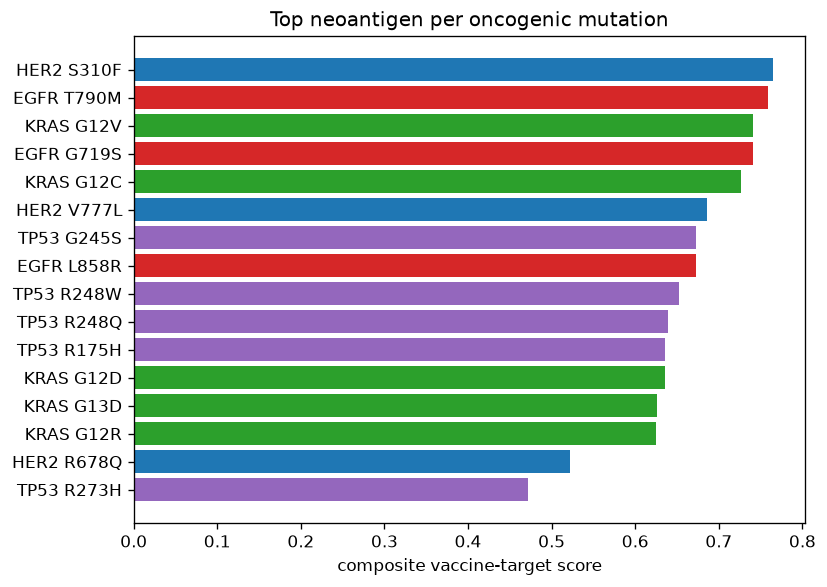

In [7]:
best = df.sort_values("composite", ascending=False).drop_duplicates(["protein", "mutation"])
best = best.sort_values("composite")
fig, ax = plt.subplots(figsize=(7, 5))
colors = {"EGFR": "#d62728", "HER2": "#1f77b4", "KRAS": "#2ca02c", "TP53": "#9467bd"}
ax.barh(best["protein"] + " " + best["mutation"], best["composite"],
        color=[colors[p] for p in best["protein"]])
ax.set_xlabel("composite vaccine-target score")
ax.set_title("Top neoantigen per oncogenic mutation")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_a_top_per_mutation.png"); plt.show()

**(b) Binding vs. immunogenic similarity.** Each point is a candidate; the best targets fall in the upper-right.

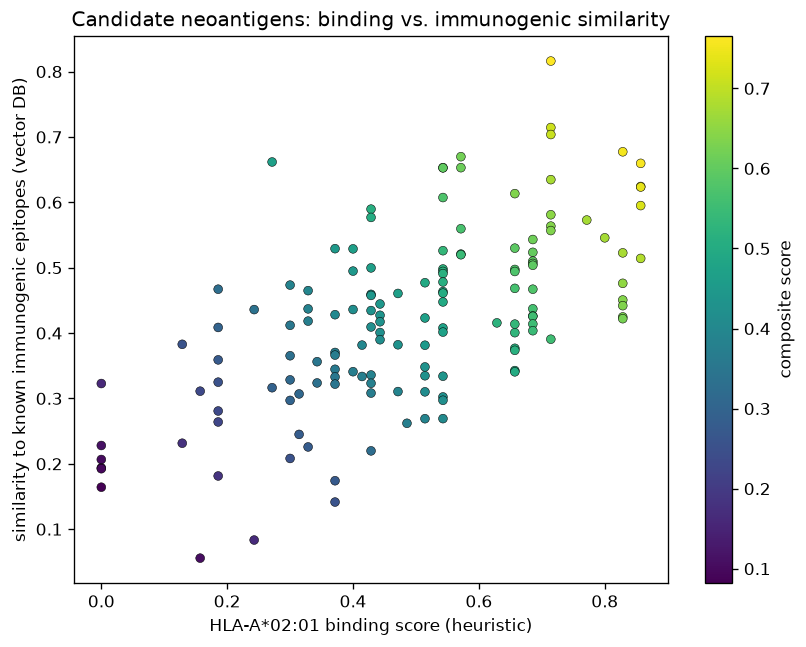

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(df["binding"], df["similarity"], c=df["composite"],
                cmap="viridis", s=28, edgecolor="k", linewidth=0.3)
ax.set_xlabel("HLA-A*02:01 binding score (heuristic)")
ax.set_ylabel("similarity to known immunogenic epitopes (vector DB)")
ax.set_title("Candidate neoantigens: binding vs. immunogenic similarity")
plt.colorbar(sc, label="composite score")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_b_binding_vs_similarity.png"); plt.show()

**(c) Embedding space (PCA).** We project the 47-d vectors of known epitopes and our
candidates to 2-D. Candidates that land *inside* the cloud of known immunogenic epitopes
are, by construction, the ones the vector DB scores as most promising.

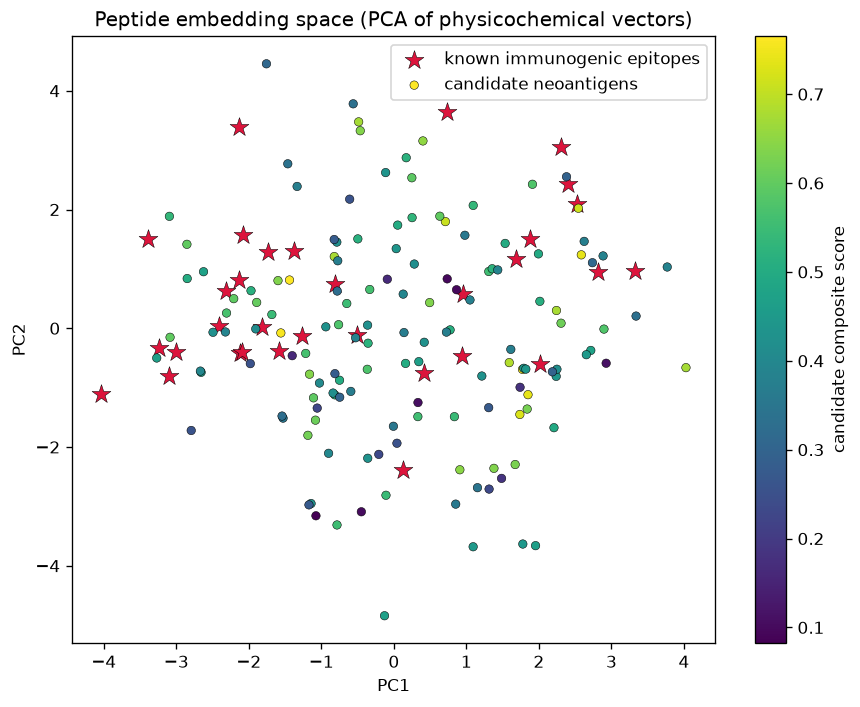

In [9]:
ref_peps = [p for p, _, _ in REFERENCE_EPITOPES]
cand_peps = df["peptide"].tolist()
X = embed_many(ref_peps + cand_peps)
xy = PCA(n_components=2, random_state=0).fit_transform(X)
n_ref = len(ref_peps)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(xy[:n_ref, 0], xy[:n_ref, 1], c="crimson", marker="*", s=140,
           label="known immunogenic epitopes", edgecolor="k", linewidth=0.3)
sc = ax.scatter(xy[n_ref:, 0], xy[n_ref:, 1], c=df["composite"], cmap="viridis",
                s=26, label="candidate neoantigens", edgecolor="k", linewidth=0.3)
ax.set_title("Peptide embedding space (PCA of physicochemical vectors)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(loc="best")
plt.colorbar(sc, label="candidate composite score")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_c_embedding_pca.png"); plt.show()

## Stage 6 — The designed vaccine

Finally we select the top candidate per mutation and concatenate them with **AAY**
proteasomal-cleavage linkers — the "string-of-beads" design used in real multi-epitope
vaccines.

In [10]:
vaccine = design_vaccine(df, top_n=8, one_per_mutation=True)
print(f"Selected {vaccine['n_epitopes']} epitopes | construct length {vaccine['length_aa']} aa\n")
display(vaccine["epitopes"][["protein", "mutation", "peptide", "binding",
                             "similarity", "nearest_antigen", "composite"]])
print("\nVaccine construct (string-of-beads):\n")
print(vaccine["construct"])

Selected 8 epitopes | construct length 93 aa



,protein,mutation,peptide,binding,similarity,nearest_antigen,composite
0,HER2,S310F,GFCTLVCPL,0.7143,0.8161,EBV BMLF1,0.7652
1,EGFR,T790M,STVQLIMQL,0.8571,0.6596,CMV pp65,0.7584
3,KRAS,G12V,LVVVGAVGV,0.8571,0.6242,Melan-A/MART-1,0.7407
4,EGFR,G719S,VLSSGAFGT,0.8571,0.6234,gp100,0.7403
5,KRAS,G12C,LVVVGACGV,0.8571,0.5950,Melan-A/MART-1,0.7261
8,HER2,V777L,MAGLGSPYV,0.8571,0.5142,Melan-A/MART-1,0.6857
11,TP53,G245S,SMNRRPILT,0.8000,0.5457,HER2/neu,0.6728
12,EGFR,L858R,ITDFGRAKL,0.7714,0.5729,WT1,0.6722



Vaccine construct (string-of-beads):

GFCTLVCPLAAYSTVQLIMQLAAYLVVVGAVGVAAYVLSSGAFGTAAYLVVVGACGVAAYMAGLGSPYVAAYSMNRRPILTAAYITDFGRAKL


## Validation — does the scoring capture real immunology?

There is no clinical ground truth for these candidates, so instead we test the *method's*
behaviour: if the binding heuristic is meaningful, the 32 **known immunogenic** reference
epitopes should score far higher than random peptides drawn from the same proteins. They do —
a clean separation, which is face-validity evidence that the scorer reflects the real
HLA-A\*02:01 motif rather than noise. (This validates the method, not any individual candidate.)

known immunogenic epitopes: mean 0.922  (100% >= 0.71)
random proteome 9-mers    : mean 0.377  (10% >= 0.71)


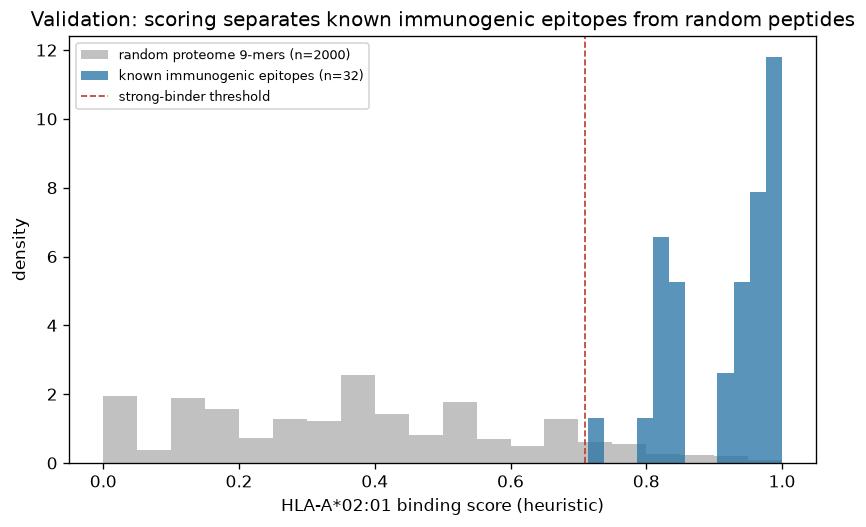

In [11]:
from vaxsim import binding_score
from vaxsim.features import PEPTIDE_LENGTH

rng = np.random.default_rng(0)
seqs = list(proteins.values())
rand_peptides = []
while len(rand_peptides) < 2000:
    s = seqs[rng.integers(len(seqs))]
    i = int(rng.integers(0, len(s) - PEPTIDE_LENGTH))
    p = s[i:i + PEPTIDE_LENGTH]
    if all(c in "ACDEFGHIKLMNPQRSTVWY" for c in p):
        rand_peptides.append(p)

ref_binding = np.array([binding_score(p) for p, _, _ in REFERENCE_EPITOPES])
rand_binding = np.array([binding_score(p) for p in rand_peptides])
print(f"known immunogenic epitopes: mean {ref_binding.mean():.3f}  ({(ref_binding>=0.71).mean()*100:.0f}% >= 0.71)")
print(f"random proteome 9-mers    : mean {rand_binding.mean():.3f}  ({(rand_binding>=0.71).mean()*100:.0f}% >= 0.71)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(rand_binding, bins=20, density=True, alpha=0.6, color="#999999",
        label=f"random proteome 9-mers (n={len(rand_binding)})")
ax.hist(ref_binding, bins=12, density=True, alpha=0.75, color="#2471A3",
        label=f"known immunogenic epitopes (n={len(ref_binding)})")
ax.axvline(0.71, color="#C0392B", linestyle="--", linewidth=1, label="strong-binder threshold")
ax.set_xlabel("HLA-A*02:01 binding score (heuristic)")
ax.set_ylabel("density")
ax.set_title("Validation: scoring separates known immunogenic epitopes from random peptides")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG}/fig_d_validation.png"); plt.show()

## Conclusions

*(Write this section in your own words for the report.)* Talking points grounded in the run above:

- The simulation reproduces the real personalized-neoantigen pipeline end-to-end:
  **protein → mutation → 9-mer neoantigens → binding + immunogenicity scoring → construct.**
- A **NoSQL vector database** is a natural fit: ranking neoantigens *is* a nearest-neighbor
  similarity search, which Chroma answers directly — something a relational `WHERE`/`JOIN`
  cannot express over peptide chemistry.
- EGFR/HER2 candidates connect the human pipeline back to the Yale canine vaccine's targets.

**Strengths:** transparent, fast, no GPU, fully reproducible.
**Limitations:** heuristic binding (not NetMHCpan), one HLA allele, physicochemical (not
learned) embeddings, no expression/proteasomal-processing filters.